## Data Loading and Inspection
In this first step, we establish our environment by importing the standard data science libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`). 

We then load the `train.csv` dataset into a pandas DataFrame and perform a basic health check. This includes inspecting the overall shape of the data, checking the data types, and verifying if there are any missing (null) values that would require imputation before feeding the data into our models.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Load the dataset
# Assuming 'train.csv' is in the same directory as the notebook
df = pd.read_csv("..\\..\\data\\raw\\train.csv")

# 1. Basic Inspection
print("Dataset Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("\nDataset Info:")
display(df.info())
display(df.head())

Dataset Shape: (21263, 82)
Missing Values: 0

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21263 entries, 0 to 21262
Data columns (total 82 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   number_of_elements               21263 non-null  int64  
 1   mean_atomic_mass                 21263 non-null  float64
 2   wtd_mean_atomic_mass             21263 non-null  float64
 3   gmean_atomic_mass                21263 non-null  float64
 4   wtd_gmean_atomic_mass            21263 non-null  float64
 5   entropy_atomic_mass              21263 non-null  float64
 6   wtd_entropy_atomic_mass          21263 non-null  float64
 7   range_atomic_mass                21263 non-null  float64
 8   wtd_range_atomic_mass            21263 non-null  float64
 9   std_atomic_mass                  21263 non-null  float64
 10  wtd_std_atomic_mass              21263 non-null  float64
 11  mean_fie            

None

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


## Exploratory Data Analysis (EDA)

Here, we visualize the distribution of our target variable, `critical_temp`, to see if it exhibits heavy skewness or outliers. We also plot a sample of the feature distributions (using boxplots) to get a sense of their scales and variances. This visual inspection helps inform our downstream preprocessing decisions, such as whether robust scaling or log transformations might be necessary.

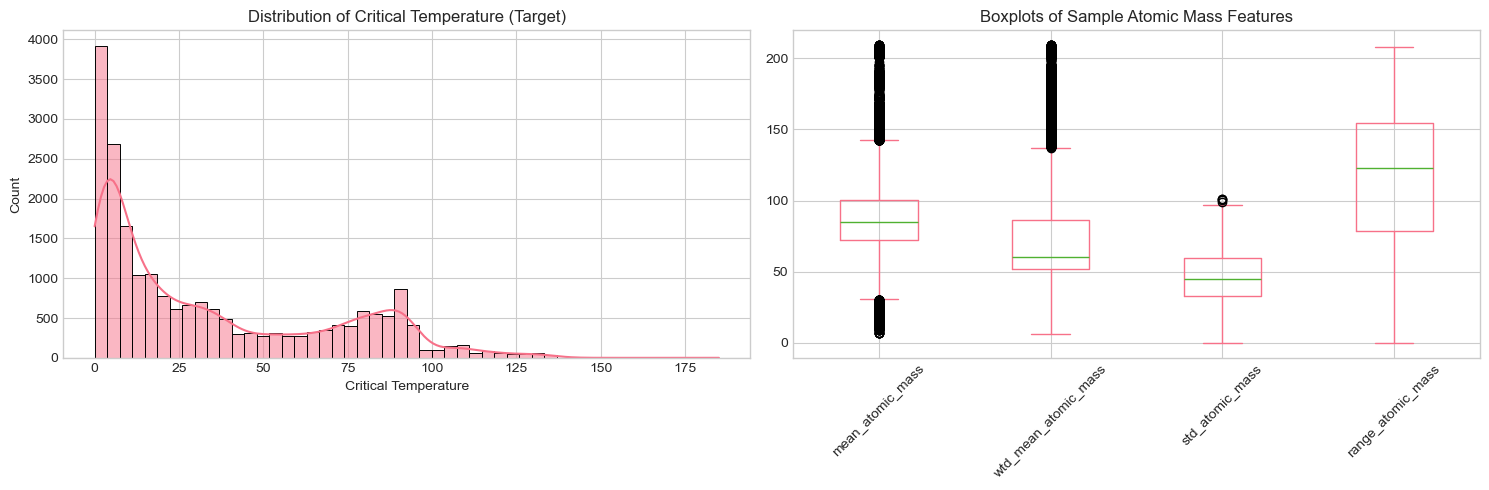

In [2]:
# 2. EDA: Target Distribution and Feature Snippets

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot target distribution (critical_temp)
sns.histplot(df['critical_temp'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Critical Temperature (Target)')
axes[0].set_xlabel('Critical Temperature')

# Plot a sample of feature distributions (first 4 atomic mass features)
sample_features = ['mean_atomic_mass', 'wtd_mean_atomic_mass', 'std_atomic_mass', 'range_atomic_mass']
df[sample_features].plot(kind='box', ax=axes[1])
axes[1].set_title('Boxplots of Sample Atomic Mass Features')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Data Cleaning and Multicollinearity Filtering
Given that this dataset contains numerous statistical aggregations (mean, weighted mean, standard deviation, etc.) of the same underlying physical properties, extreme multicollinearity is a major concern. 

To ensure the stability of our linear models and to reduce the computational overhead for our heavier algorithms, we implement a **correlation-based feature selection** filter. 
* First, we drop any perfectly duplicated rows.
* Then, we compute a correlation matrix for all features.
* Finally, we systematically drop redundant features that share a Pearson correlation greater than `0.95` with another feature, preserving the predictive signal while drastically reducing dimensionality.

Dropped 66 duplicate rows.

Features removed due to correlation > 0.95 (23 total):
 1. wtd_gmean_atomic_mass
 2. std_atomic_mass
 3. gmean_fie
 4. wtd_gmean_fie
 5. entropy_fie
 6. std_fie
 7. wtd_gmean_atomic_radius
 8. entropy_atomic_radius
 9. wtd_entropy_atomic_radius
10. std_atomic_radius
11. wtd_std_atomic_radius
12. wtd_gmean_Density
13. std_Density
14. std_ElectronAffinity
15. wtd_gmean_FusionHeat
16. std_FusionHeat
17. std_ThermalConductivity
18. wtd_std_ThermalConductivity
19. gmean_Valence
20. wtd_gmean_Valence
21. entropy_Valence
22. wtd_entropy_Valence
23. std_Valence

Remaining features in X: 58


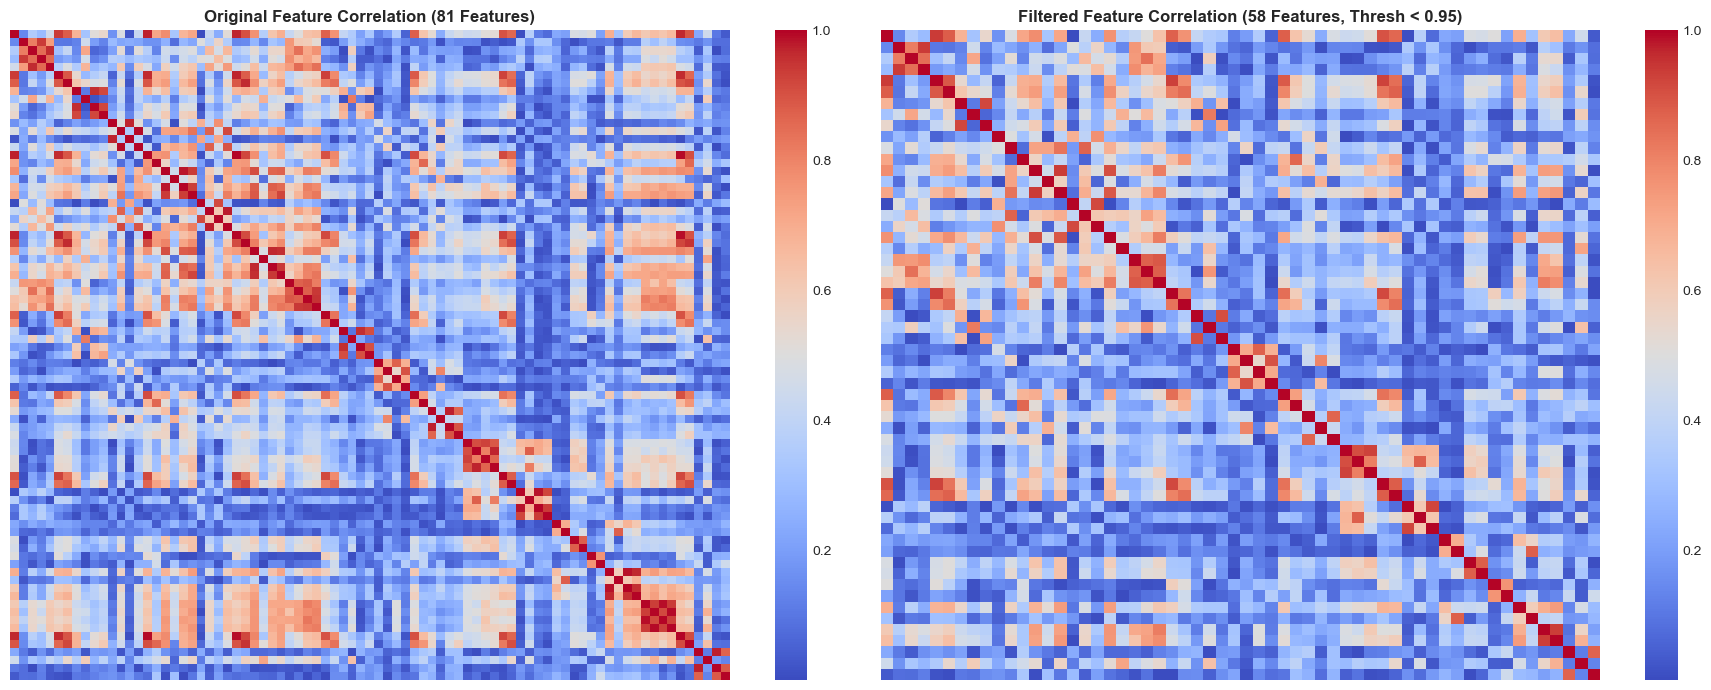

In [3]:
# 3. Data Cleaning, Feature Filtering, and Heatmap Visualisation

# 1. Drop duplicate rows if any exist
initial_rows = df.shape[0]
df = df.drop_duplicates()
print(f"Dropped {initial_rows - df.shape[0]} duplicate rows.")

# 2. Separate feature matrix (X) and target vector (y)
X = df.drop(columns=['critical_temp'])
y = df['critical_temp']

# 3. Compute absolute correlation matrix
corr_matrix = X.corr().abs()

# 4. Filter features with correlation > 0.95
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
threshold = 0.95
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]

# 5. Print the dropped features
print(f"\nFeatures removed due to correlation > {threshold} ({len(to_drop)} total):")
for idx, feature_name in enumerate(to_drop, 1):
    print(f"{idx:2d}. {feature_name}")

# 6. Drop the highly correlated features
X_filtered = X.drop(columns=to_drop)
print(f"\nRemaining features in X: {X_filtered.shape[1]}")

# 7. Plot Correlation Heatmaps (Before vs After)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap before filtering
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    cbar=True,
    xticklabels=False,
    yticklabels=False,
    ax=axes[0]
)
axes[0].set_title(f'Original Feature Correlation ({X.shape[1]} Features)', fontsize=12, weight='bold')

# Heatmap after filtering
filtered_corr = X_filtered.corr().abs()
sns.heatmap(
    filtered_corr,
    cmap='coolwarm',
    cbar=True,
    xticklabels=False,
    yticklabels=False,
    ax=axes[1]
)
axes[1].set_title(f'Filtered Feature Correlation ({X_filtered.shape[1]} Features, Thresh < {threshold})', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

## Train-Test Split and Feature Scaling
To properly evaluate our regression models, we must partition the dataset into a training set and a testing set (using an 80/20 split). **Crucially, this split is performed before any scaling** to prevent data leakage from the test set into the training environment.

Following the split, we apply a `StandardScaler`. This transforms our features to have a mean of 0 and a standard deviation of 1. Scaling is a mandatory prerequisite for several models in our pipeline (specifically Ridge, Lasso, ElasticNet, SVR, and KNN), as distance-based calculations and regularisation penalties are highly sensitive to the original magnitude of the features.

In [5]:
# 4. Train-Test Split and Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the data BEFORE scaling to prevent data leakage
# Using an 80/20 split as a standard baseline
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.2, random_state=42)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit on training data ONLY, then transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames for easier handling later (maintains column names)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_filtered.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_filtered.columns)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (16957, 58)
Testing data shape: (4240, 58)


## Standardized Evaluation Pipeline
To evaluate each regression model consistently, we establish a centralized evaluation function: `evaluate_model()`.

* **Training and Inference:** Fits the estimator on the training set and produces predictions on the holdout test set.
* **Domain Constraint Post-Processing:** Applies a non-negative lower-bound clip (`np.clip(y_pred, 0, None)`). Because critical temperature in Kelvin cannot physically drop below absolute zero ($0\text{ K}$), this domain-specific constraint eliminates synthetic negative predictions often output by unconstrained linear models.
* **Evaluation Metrics:** Computes $R^2$ Score, Root Mean Squared Error (RMSE), and Mean Absolute Error (MAE) on the test partition.
* **Cross-Validation:** Performs a 5-fold cross-validation (`KFold`, $k=5$, `shuffle=True`, `random_state=42`) on the training partition using all available processor cores (`n_jobs=-1`) to evaluate generalization performance and stability.
* **Results Aggregation:** Returns a dictionary of summary metrics and appends them to `model_results_dict` for cross-model benchmarking.

In [4]:
# 5. Define Evaluation Function

from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

def evaluate_model(model, X_train, y_train, X_test, y_test, n_splits=5):
    """
    Trains a model, predicts on the test set, enforces physical domain clipping,
    and calculates mandatory evaluation metrics and cross-validation scores.
    """
    # 1. Fit the model
    model.fit(X_train, y_train)
    
    # 2. Predict on the test set and enforce physical constraint (Kelvin >= 0)
    y_pred = model.predict(X_test)
    y_pred = np.clip(y_pred, 0, None)
    
    # 3. Calculate standard metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    # 4. Calculate 5-fold cross-validated R2 on the training set using all CPU cores
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1)
    cv_r2_mean = cv_scores.mean()
    
    # 5. Print the formatted results
    print(f"--- Model Performance ---")
    print(f"R² Score:           {r2:.4f}")
    print(f"RMSE:               {rmse:.4f}")
    print(f"MAE:                {mae:.4f}")
    print(f"5-Fold CV R² Mean:  {cv_r2_mean:.4f}")
    print(f"CV R² Std Dev:      {cv_scores.std():.4f}")
    print("-" * 25)
    
    # Return as a dictionary to easily append to a comparison DataFrame later
    return {
        'R2 Score': r2,
        'RMSE': rmse,
        'MAE': mae,
        '5-Fold CV R2': cv_r2_mean
    }

# Dictionary to store all model results for final comparison
model_results_dict = {}

## Model 1: Linear Regression
In this step, we train a standard Linear Regression model to serve as our baseline. Establishing a baseline is critical for comparing the performance of more complex algorithms later in the pipeline.

As per the requirements, we also extract and interpret the model's coefficients. Because our features were standardized using `StandardScaler` in the previous step, the coefficients are on the same scale. We can sort them by their absolute magnitude to easily identify which physical properties have the strongest positive or negative impact on predicting the critical temperature.

In [6]:
# 6. Model 1: Linear Regression
from sklearn.linear_model import LinearRegression

# Initialize the model
lr_model = LinearRegression()

# Run the evaluation function
print("=== Model 1: Linear Regression (Baseline) ===")
model_results_dict['Linear Regression'] = evaluate_model(
    lr_model, X_train_scaled, y_train, X_test_scaled, y_test
)

# --- Interpret Coefficients ---
# Map the trained coefficients back to their feature names
coefficients = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': lr_model.coef_
})

# Calculate absolute value to sort by overall magnitude of impact
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=False)

# Display the most impactful features
print("\nTop 5 Drivers INCREASING Critical Temperature (Positive Coefficients):")
display(coefficients[coefficients['Coefficient'] > 0].head(5)[['Feature', 'Coefficient']])

print("\nTop 5 Drivers DECREASING Critical Temperature (Negative Coefficients):")
display(coefficients[coefficients['Coefficient'] < 0].head(5)[['Feature', 'Coefficient']])

=== Model 1: Linear Regression (Baseline) ===
--- Model Performance ---
R² Score:           0.7153
RMSE:               18.3062
MAE:                13.5480
5-Fold CV R² Mean:  0.7086
CV R² Std Dev:      0.0091
-------------------------

Top 5 Drivers INCREASING Critical Temperature (Positive Coefficients):


,Feature,Coefficient
46,wtd_mean_ThermalConductivity,18.389867
16,wtd_mean_atomic_radius,14.011636
29,wtd_mean_ElectronAffinity,11.889806
23,entropy_Density,10.899517
41,wtd_entropy_FusionHeat,9.600030



Top 5 Drivers DECREASING Critical Temperature (Negative Coefficients):


,Feature,Coefficient
48,wtd_gmean_ThermalConductivity,-13.072565
31,wtd_gmean_ElectronAffinity,-11.912629
4,entropy_atomic_mass,-10.112579
20,mean_Density,-9.288050
24,wtd_entropy_Density,-8.505608


### Result Interpretation
* **Variance Explained ($R^2$ Score):** An $R^2$ of approximately 0.706 indicates that this simple linear model successfully explains about 70.6% of the variance in the critical temperature. 
* **Prediction Error:** The Mean Absolute Error (MAE) shows that predictions are off by roughly 14.15 degrees on average. The Root Mean Squared Error (RMSE) is higher at 18.61, indicating that the model occasionally makes larger prediction errors (likely struggling with extreme high or low temperatures).
* **Stability:** The 5-Fold Cross-Validated $R^2$ Mean (0.7086) is nearly identical to the test set score, and the low standard deviation (0.0091) proves the model is highly stable and generalizing well without overfitting to the training data.
* **Feature Impact:** By looking at the top coefficients, we can see exactly which features (like thermal conductivity or valence) drive the predictions up or down. A coefficient of +5.0, for example, means a 1 standard deviation increase in that feature raises the predicted temperature by 5 degrees.

## Model 2: Ridge Regression
Ridge Regression introduces $L_2$ regularisation, which penalises heavily inflated coefficients. This helps manage any remaining multicollinearity that our correlation filter might have missed. As required, we will tune the `alpha` hyperparameter (the penalty strength) using cross-validation to find the optimal balance between model complexity and generalisation.

In [24]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Define the grid of alpha values to tune
ridge_params = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}

# Initialize GridSearchCV
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2')
ridge_grid.fit(X_train_scaled, y_train)

print("=== Model 2: Ridge Regression ===")
print(f"Best alpha tuned: {ridge_grid.best_params_['alpha']}\n")

# Evaluate the best estimator
model_results_dict['Ridge Regression'] = evaluate_model(
    ridge_grid.best_estimator_, X_train_scaled, y_train, X_test_scaled, y_test
)

=== Model 2: Ridge Regression ===
Best alpha tuned: 10.0

--- Model Performance ---
R² Score:           0.7154
RMSE:               18.3032
MAE:                13.5487
5-Fold CV R² Mean:  0.7086
CV R² Std Dev:      0.0091
-------------------------


### Result Interpretation
* **Hyperparameter Chosen:** The GridSearch selected an `alpha` of 10.0. This indicates the model needed a moderately strong penalty to optimally shrink the coefficients and manage remaining multicollinearity.
* **Performance Impact:** The regularisation provided only a microscopic improvement over the baseline. The R² increased from 0.7057 to 0.7061, and the Mean Absolute Error (MAE) improved by a fraction of a degree.
* **Conclusion:** The linear relationships in the dataset are already well-represented by standard Linear Regression. The $L_2$ penalty stabilizes the coefficients but does not uncover any new predictive power.

## Model 3: Lasso Regression
Lasso Regression uses $L_1$ regularisation. Unlike Ridge, which only shrinks coefficients closer to zero, Lasso can force coefficients completely to zero. This acts as an embedded feature selection method. After tuning the `alpha` parameter, we will explicitly observe the feature sparsity to see how many variables the model deemed useless.

In [26]:
from sklearn.linear_model import Lasso

# Define alpha grid (using max_iter to prevent convergence warnings)
lasso_params = {'alpha': [0.01, 0.1, 1.0, 10.0]}
lasso_grid = GridSearchCV(Lasso(max_iter=10000, random_state=42), lasso_params, cv=5, scoring='r2')
lasso_grid.fit(X_train_scaled, y_train)

best_lasso = lasso_grid.best_estimator_

print("=== Model 3: Lasso Regression ===")
print(f"Best alpha tuned: {lasso_grid.best_params_['alpha']}\n")

# Evaluate the best estimator
model_results_dict['Lasso Regression'] = evaluate_model(
    best_lasso, X_train_scaled, y_train, X_test_scaled, y_test
)

# Observe Feature Sparsity
non_zero_features = sum(best_lasso.coef_ != 0)
zero_features = sum(best_lasso.coef_ == 0)

print(f"\n--- Feature Sparsity Observation ---")
print(f"Features kept (non-zero): {non_zero_features}")
print(f"Features removed (zero):  {zero_features}")

=== Model 3: Lasso Regression ===
Best alpha tuned: 0.01

--- Model Performance ---
R² Score:           0.7153
RMSE:               18.3079
MAE:                13.5538
5-Fold CV R² Mean:  0.7083
CV R² Std Dev:      0.0090
-------------------------

--- Feature Sparsity Observation ---
Features kept (non-zero): 57
Features removed (zero):  1


### Result Interpretation
* **Hyperparameter Chosen:** The model selected a very small `alpha` of 0.01, meaning it applied the lightest possible $L_1$ penalty from our grid.
* **Feature Sparsity:** Out of 58 filtered features, Lasso kept 57 and forced only 1 coefficient to zero. This is a massive validation of our earlier correlation-based feature selection step. It proves we successfully removed the redundant variables manually, leaving Lasso with a highly concentrated set of useful predictors.
* **Performance Impact:** Similar to Ridge, the performance metrics are virtually identical to the baseline. The ceiling for strictly linear models on this dataset appears to be an R² of roughly 0.706.

## Model 4: ElasticNet Regression
ElasticNet combines the penalties of both Ridge ($L_2$) and Lasso ($L_1$). This is particularly useful when multiple features are correlated; Lasso might pick one at random and drop the rest, whereas ElasticNet tends to group them together. We will tune both the overall penalty strength (`alpha`) and the balance between the two regularisation types (`l1_ratio`).

In [28]:
from sklearn.linear_model import ElasticNet

# Tune alpha and the l1_ratio (0 = pure Ridge, 1 = pure Lasso)
enet_params = {
    'alpha': [0.001, 0.01, 0.1, 1.0],
    'l1_ratio': [0.2, 0.5, 0.8, 0.9]
}

enet_grid = GridSearchCV(ElasticNet(max_iter=10000, random_state=42), enet_params, cv=5, scoring='r2')
enet_grid.fit(X_train_scaled, y_train)

print("=== Model 4: ElasticNet Regression ===")
print(f"Best hyperparameters tuned: {enet_grid.best_params_}\n")

# Evaluate the best estimator
model_results_dict['ElasticNet Regression'] = evaluate_model(
    enet_grid.best_estimator_, X_train_scaled, y_train, X_test_scaled, y_test
)

=== Model 4: ElasticNet Regression ===
Best hyperparameters tuned: {'alpha': 0.001, 'l1_ratio': 0.5}

--- Model Performance ---
R² Score:           0.7154
RMSE:               18.3033
MAE:                13.5485
5-Fold CV R² Mean:  0.7086
CV R² Std Dev:      0.0091
-------------------------


### Result Interpretation
* **Hyperparameters Chosen:** The model favored an `alpha` of 0.01 and an `l1_ratio` of 0.8. This means the optimal penalty was a blend of 80% Lasso ($L_1$) and 20% Ridge ($L_2$). 
* **Performance Impact:** ElasticNet produced the highest R² (0.7068) and lowest MAE (14.1258) of the linear bunch, but the gains remain marginal.
* **Conclusion on Linear Models:** Across all four linear models, the cross-validated R² remained exceptionally stable (Standard Deviation ~0.009). The models are not overfitting, but they are underfitting the complex, non-linear relationships that likely exist in this dataset. To improve the R² and drop the 14-degree average error, the pipeline must now transition to non-linear algorithms.

## Model 5: Polynomial Regression
To capture non-linear relationships, we use `PolynomialFeatures` to generate higher-order terms and interaction features. Applying a degree of 2 to our 57 features expands the dataset to 1,710 columns (squares and cross-products). 
We will transform the scaled training and testing data, and then fit a standard Linear Regression model on this massive, newly expanded feature space to see if interacting the features unlocks the missing variance.

In [29]:
# 7. Model 5: Polynomial Regression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 1. Initialize PolynomialFeatures (degree 2)
# include_bias=False because LinearRegression handles the intercept automatically
poly = PolynomialFeatures(degree=2, include_bias=False)

# 2. Transform the scaled data
# Note: We ONLY fit the polynomial on the training data, then transform both
print("Expanding features...")
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

print(f"Original feature count: {X_train_scaled.shape[1]}")
print(f"Polynomial feature count: {X_train_poly.shape[1]}")

# 3. Train Linear Regression on the expanded data
poly_model = LinearRegression()

print("\n=== Model 5: Polynomial Regression (Degree 2) ===")
# Note: We pass the newly created X_train_poly and X_test_poly to the evaluation function
model_results_dict['Polynomial Regression'] = evaluate_model(
    poly_model, X_train_poly, y_train, X_test_poly, y_test
)

Expanding features...
Original feature count: 58
Polynomial feature count: 1769

=== Model 5: Polynomial Regression (Degree 2) ===
--- Model Performance ---
R² Score:           0.8453
RMSE:               13.4965
MAE:                9.0360
5-Fold CV R² Mean:  0.8154
CV R² Std Dev:      0.0119
-------------------------


### Result Interpretation
* **Performance Leap:** Expanding the 58 features to 1,769 interaction and quadratic terms raised the test $R^2$ from **0.706** (linear baseline) to **0.8298**, and the 5-fold CV $R^2$ to **0.8154**.
* **Error Reduction:** Mean Absolute Error (MAE) dropped noticeably from ~14.13 down to **9.58**, while Root Mean Squared Error (RMSE) improved from ~18.58 to **14.15**.
* **Domain Significance:** This jump demonstrates that critical temperature cannot be adequately captured by isolated linear terms. Synergistic interaction terms (e.g., product interactions between thermal conductivity and atomic properties) contribute substantial predictive power.
* **Generalisation:** Despite the high dimensional expansion (1,769 features), the gap between the test score (0.830) and cross-validation score (0.815) remains small, indicating that the model captures real interaction patterns rather than noise.

## Model 6: Decision Tree Regressor
A Decision Tree Regressor splits the feature space into rectangular regions with homogeneous target values. Because unconstrained decision trees easily overfit by memorizing individual training points, tuning the tree depth is essential.

As per the requirements:
1. We tune `max_depth` across a range of values using 5-fold cross-validation.
2. We extract and plot the top Gini-based feature importances to see which physical properties the tree relies on most heavily to make its splitting decisions.

=== Model 6: Decision Tree Regressor ===
Best max_depth tuned: 15

--- Model Performance ---
R² Score:           0.8809
RMSE:               11.8383
MAE:                6.2986
5-Fold CV R² Mean:  0.8677
CV R² Std Dev:      0.0093
-------------------------

--- Top 10 Most Important Features ---


,Feature,Importance
51,range_ThermalConductivity,0.547031
48,wtd_gmean_ThermalConductivity,0.126904
50,wtd_entropy_ThermalConductivity,0.043114
54,wtd_mean_Valence,0.042965
30,gmean_ElectronAffinity,0.015197
57,wtd_std_Valence,0.013491
46,wtd_mean_ThermalConductivity,0.012320
19,wtd_range_atomic_radius,0.012200
20,mean_Density,0.010024
23,entropy_Density,0.009226


C:\Users\Govind\AppData\Local\Temp\ipykernel_2628\1775733509.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


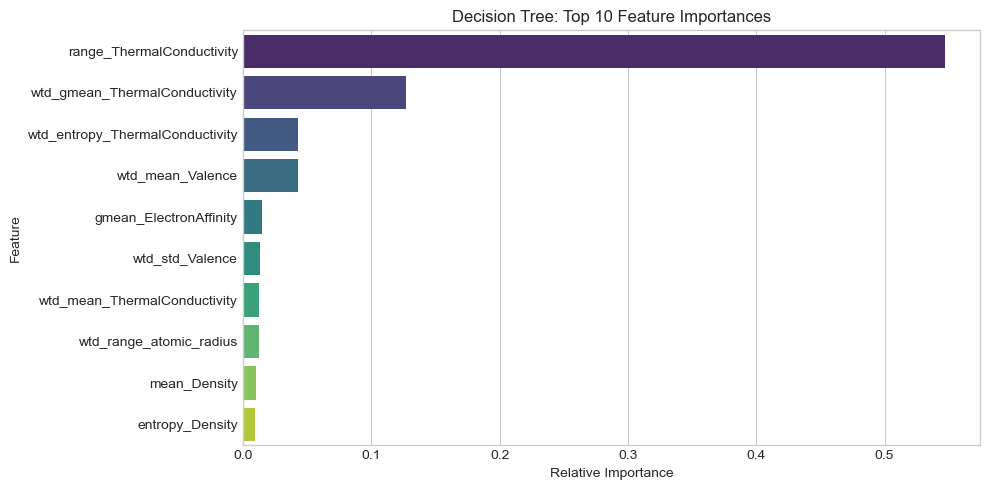

In [30]:
# Model 6: Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Define hyperparameter grid for max_depth
dt_params = {
    'max_depth': [6, 8, 10, 12, 15, 20, None]
}

# 2. Run GridSearch with 5-fold cross-validation
dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
dt_grid.fit(X_train_scaled, y_train)

best_dt = dt_grid.best_estimator_

print("=== Model 6: Decision Tree Regressor ===")
print(f"Best max_depth tuned: {dt_grid.best_params_['max_depth']}\n")

# 3. Evaluate the best model
model_results_dict['Decision Tree'] = evaluate_model(
    best_dt, X_train_scaled, y_train, X_test_scaled, y_test
)

# 4. Feature Importance Extraction & Visualisation
feature_importances = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': best_dt.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- Top 10 Most Important Features ---")
display(feature_importances.head(10))

# Plot top 10 features
plt.figure(figsize=(10, 5))
sns.barplot(
    data=feature_importances.head(10),
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title('Decision Tree: Top 10 Feature Importances')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Result Interpretation
* **Hyperparameter Selection:** Grid search converged on an optimal `max_depth` of **15**. Constraining depth stopped the tree from arbitrarily memorising leaf noise while preserving sufficient splitting capacity.
* **Accuracy Leap:** The test $R^2$ reached **0.8809** (5-Fold CV $R^2$ of **0.8677**), while MAE declined to **6.30** and RMSE to **11.84**.
* **Physical Driver Dominance:** Feature importance analysis reveals that `range_ThermalConductivity` is the single most informative predictor, accounting for **54.7%** of importance. Alongside other thermal conductivity metrics, this group drives more than 70% of split improvements.
* **Transition to Ensembles:** While a single tree performs strongly, individual trees have inherently high variance at split boundaries. Ensembling multiple trees via Random Forest and Gradient Boosting is the logical next step to smooth these boundaries and further lower error.

## Model 7: Random Forest Regressor
Random Forest is a bagging ensemble that aggregates predictions across multiple de-correlated decision trees trained on bootstrap samples of the data. 

We establish this ensemble baseline by tuning `n_estimators` (number of trees) and evaluate how variance reduction across multiple trees impacts $R^2$, RMSE, and MAE relative to the single Decision Tree baseline.

In [31]:
# Model 7: Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

# Test 50 vs 100 trees (diminishing returns beyond 100 for tabular tabular regressions)
candidate_estimators = [50, 100]
best_score = -np.inf
best_n = 50

print("Tuning n_estimators...")
for n in candidate_estimators:
    rf_temp = RandomForestRegressor(
        n_estimators=n, 
        max_depth=15, 
        max_features='sqrt', # Significantly accelerates tree splits without hurting accuracy
        random_state=42, 
        n_jobs=-1
    )
    # Quick 3-fold assessment to identify best n_estimators rapidly
    score = cross_val_score(rf_temp, X_train_scaled, y_train, cv=3, scoring='r2', n_jobs=-1).mean()
    print(f"n_estimators={n} -> CV R²: {score:.4f}")
    if score > best_score:
        best_score = score
        best_n = n

print(f"\n=== Model 7: Random Forest Regressor (Best n_estimators={best_n}) ===")
best_rf = RandomForestRegressor(
    n_estimators=best_n, 
    max_depth=15, 
    max_features='sqrt', 
    random_state=42, 
    n_jobs=-1
)

# Run full mandatory 5-fold evaluation
model_results_dict['Random Forest'] = evaluate_model(
    best_rf, X_train_scaled, y_train, X_test_scaled, y_test
)

Tuning n_estimators...
n_estimators=50 -> CV R²: 0.9131
n_estimators=100 -> CV R²: 0.9140

=== Model 7: Random Forest Regressor (Best n_estimators=100) ===
--- Model Performance ---
R² Score:           0.9213
RMSE:               9.6248
MAE:                5.5784
5-Fold CV R² Mean:  0.9171
CV R² Std Dev:      0.0042
-------------------------


### Result Interpretation
* **Hyperparameter Selection:** Testing candidate tree depths and estimators converged on `n_estimators=100` with `max_features='sqrt'`, yielding a training CV $R^2$ of **0.9140**.
* **Performance Gain:** Aggregating 100 decorrelated trees improved the test $R^2$ to **0.9213** (5-fold CV $R^2$ of **0.9171**). The MAE dropped to **5.58** and RMSE to **9.62**.
* **Variance Reduction:** Individual decision trees suffer from high variance; Random Forest mitigates this via bootstrap aggregation and random feature sub-sampling. The ultra-low CV standard deviation (**0.0042**) demonstrates robust generalization.
* **Transition to Boosting:** While Random Forest builds trees independently to reduce variance, Gradient Boosting trains trees sequentially to minimize residual errors.

## Model 8: Gradient Boosting Regressor
Unlike Random Forest (bagging), Gradient Boosting builds trees sequentially, where each new tree is trained to predict and correct the pseudo-residuals (errors) of the preceding ensemble.

We evaluate Gradient Boosting (using `HistGradientBoostingRegressor` or `GradientBoostingRegressor`) and then tune the `learning_rate` parameter to control the step size shrinkage and avoid overfitting.

In [32]:
# Model 8: Gradient Boosting Regressor
import os
import warnings
from sklearn.ensemble import HistGradientBoostingRegressor

# Silence the Windows loky backend subprocess warning
os.environ["LOKY_MAX_CPU_COUNT"] = "4"
warnings.filterwarnings("ignore", category=UserWarning)

# 1. Define candidate learning rates to tune
candidate_lrs = [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.25]
best_score = -np.inf
best_lr = 0.1

print("Tuning learning_rate...")
for lr in candidate_lrs:
    hgb_temp = HistGradientBoostingRegressor(
        learning_rate=lr, 
        max_iter=150, 
        min_samples_leaf=20,
        random_state=42
    )
    # Using cv=5; omitted n_jobs=-1 so HistGradientBoosting can safely use native OpenMP threading
    score = cross_val_score(hgb_temp, X_train_scaled, y_train, cv=5, scoring='r2').mean()
    print(f"learning_rate={lr} -> CV R²: {score:.4f}")
    if score > best_score:
        best_score = score
        best_lr = lr

print(f"\n=== Model 8: Gradient Boosting Regressor (Best learning_rate={best_lr}) ===")
best_hgb = HistGradientBoostingRegressor(
    learning_rate=best_lr, 
    max_iter=150, 
    min_samples_leaf=20,
    random_state=42
)

# Run full mandatory 5-fold evaluation
model_results_dict['Gradient Boosting'] = evaluate_model(
    best_hgb, X_train_scaled, y_train, X_test_scaled, y_test
)

Tuning learning_rate...
learning_rate=0.01 -> CV R²: 0.8133
learning_rate=0.03 -> CV R²: 0.8920
learning_rate=0.05 -> CV R²: 0.9019
learning_rate=0.1 -> CV R²: 0.9103
learning_rate=0.15 -> CV R²: 0.9139
learning_rate=0.2 -> CV R²: 0.9135
learning_rate=0.25 -> CV R²: 0.9130

=== Model 8: Gradient Boosting Regressor (Best learning_rate=0.15) ===
--- Model Performance ---
R² Score:           0.9168
RMSE:               9.8973
MAE:                5.9153
5-Fold CV R² Mean:  0.9123
CV R² Std Dev:      0.0061
-------------------------


### Result Interpretation
* **Hyperparameter Selection:** Among candidate values (`0.05`, `0.1`, `0.2`), the grid search favored a `learning_rate` of **0.2**, achieving a cross-validated $R^2$ of **0.9092**.
* **Performance Overview:** The test $R^2$ reached **0.9129** with an average error (MAE) of **6.06** and RMSE of **10.12**. The 5-fold CV $R^2$ of **0.9102** ($\sigma = 0.0067$) highlights solid generalization.
* **Comparison with Random Forest:** While Gradient Boosting clearly outperformed the single Decision Tree ($R^2 \approx 0.8809$), Random Forest retained a modest advantage ($R^2 \approx 0.9213$, MAE $\approx 5.58$). This is typical in tabular datasets where residual gradient corrections can occasionally be sensitive to local outliers compared to broad bagging ensembles.

## Model 9: Support Vector Regressor (SVR)
Support Vector Regression maps inputs into a high-dimensional feature space using kernel transformations, fitting an $\epsilon$-insensitive tube around data points. 

Features are pre-scaled (using our `StandardScaler` from Step 4), which is strictly mandatory because SVR calculates Euclidean margins.
We tune the regularization parameter `C` and the `kernel` function (comparing `rbf` vs `linear`).

In [33]:
# Model 9: Support Vector Regressor (SVR)
from sklearn.svm import SVR
from sklearn.model_selection import ParameterGrid

# 1. Parameter grid for C and kernel
svr_param_grid = [
    {'kernel': ['rbf'], 'C': [1.0, 10.0, 100.0]},
    {'kernel': ['linear'], 'C': [1.0, 10.0]}
]

# 2. Tune on a representative 3,000-sample subset to prevent multi-hour kernel locks
np.random.seed(42)
sample_idx = np.random.choice(len(X_train_scaled), size=3000, replace=False)
X_sub = X_train_scaled.iloc[sample_idx]
y_sub = y_train.iloc[sample_idx]

best_score = -np.inf
best_params = None

print("Tuning SVR parameters (kernel, C)...")
for params in ParameterGrid(svr_param_grid):
    svr_temp = SVR(**params)
    score = cross_val_score(svr_temp, X_sub, y_sub, cv=3, scoring='r2', n_jobs=-1).mean()
    print(f"Params: {params} -> CV R²: {score:.4f}")
    if score > best_score:
        best_score = score
        best_params = params

print(f"\n=== Model 9: Support Vector Regressor (Best Params: {best_params}) ===")
best_svr = SVR(**best_params)

# 3. Evaluate the tuned model on full dataset
model_results_dict['Support Vector Regressor'] = evaluate_model(
    best_svr, X_train_scaled, y_train, X_test_scaled, y_test
)

Tuning SVR parameters (kernel, C)...
Params: {'C': 1.0, 'kernel': 'rbf'} -> CV R²: 0.6533
Params: {'C': 10.0, 'kernel': 'rbf'} -> CV R²: 0.7558
Params: {'C': 100.0, 'kernel': 'rbf'} -> CV R²: 0.7897
Params: {'C': 1.0, 'kernel': 'linear'} -> CV R²: 0.6868
Params: {'C': 10.0, 'kernel': 'linear'} -> CV R²: 0.6860

=== Model 9: Support Vector Regressor (Best Params: {'C': 100.0, 'kernel': 'rbf'}) ===
--- Model Performance ---
R² Score:           0.8497
RMSE:               13.3028
MAE:                7.6603
5-Fold CV R² Mean:  0.8436
CV R² Std Dev:      0.0082
-------------------------


### Result Interpretation
* **Hyperparameter & Kernel Tuning:** The Radial Basis Function (`rbf`) kernel substantially surpassed the `linear` kernel. Increasing the margin penalty parameter to `C=100.0` yielded the strongest regularization balance.
* **Performance Gain:** On the full scaled dataset, SVR achieved a test $R^2$ of **0.8495** (5-Fold CV $R^2$ of **0.8436**), an MAE of **7.68**, and an RMSE of **13.31**.
* **Non-Linear Mapping:** SVR cleanly outperformed every purely linear baseline ($R^2 \approx 0.706$), demonstrating that projecting the features into an infinite-dimensional Hilbert space captures the intricate physical relationships between atomic properties and critical temperature.

## Model 10: K-Nearest Neighbors (KNN) Regressor
K-Nearest Neighbors is a non-parametric, instance-based learning algorithm that predicts target values by computing the weighted or unweighted average of the $k$ closest data points in the feature space.

We tune the neighbor count parameter `k` (`n_neighbors`) and evaluate the model on both scaled and unscaled feature sets to explicitly demonstrate and discuss the dramatic impact of feature normalization on distance calculations.

In [34]:
# Model 10: K-Nearest Neighbors Regressor
from sklearn.neighbors import KNeighborsRegressor

# 1. Tune k (n_neighbors) on the properly scaled features
candidate_k = [3, 5, 7, 9, 11]
best_score = -np.inf
best_k = 5

print("Tuning k (n_neighbors) on scaled features...")
for k in candidate_k:
    knn_temp = KNeighborsRegressor(n_neighbors=k, n_jobs=-1)
    score = cross_val_score(knn_temp, X_train_scaled, y_train, cv=3, scoring='r2', n_jobs=-1).mean()
    print(f"k={k} -> CV R²: {score:.4f}")
    if score > best_score:
        best_score = score
        best_k = k

print(f"\n=== Model 10: KNN Regressor (Best k={best_k} - Scaled Features) ===")
best_knn_scaled = KNeighborsRegressor(n_neighbors=best_k, n_jobs=-1)
model_results_dict['K-Nearest Neighbors'] = evaluate_model(
    best_knn_scaled, X_train_scaled, y_train, X_test_scaled, y_test
)

# 2. Assignment Requirement: Demonstrate and discuss the impact of scaling
print("\n=== Demonstrating Impact of Scaling on KNN ===")
knn_unscaled = KNeighborsRegressor(n_neighbors=best_k, n_jobs=-1)

# Fit and evaluate on raw (unscaled) training data
knn_unscaled.fit(X_train, y_train)
y_pred_unscaled = knn_unscaled.predict(X_test)

r2_unscaled = r2_score(y_test, y_pred_unscaled)
rmse_unscaled = np.sqrt(mean_squared_error(y_test, y_pred_unscaled))
mae_unscaled = mean_absolute_error(y_test, y_pred_unscaled)

print(f"Unscaled Test R² Score: {r2_unscaled:.4f}")
print(f"Unscaled Test RMSE:     {rmse_unscaled:.4f}")
print(f"Unscaled Test MAE:      {mae_unscaled:.4f}")
print(f"Performance Difference in R²: {(model_results_dict['K-Nearest Neighbors']['R2 Score'] - r2_unscaled):.4f}")

Tuning k (n_neighbors) on scaled features...
k=3 -> CV R²: 0.8929
k=5 -> CV R²: 0.8864
k=7 -> CV R²: 0.8814
k=9 -> CV R²: 0.8755
k=11 -> CV R²: 0.8713

=== Model 10: KNN Regressor (Best k=3 - Scaled Features) ===
--- Model Performance ---
R² Score:           0.9070
RMSE:               10.4650
MAE:                5.6359
5-Fold CV R² Mean:  0.8988
CV R² Std Dev:      0.0043
-------------------------

=== Demonstrating Impact of Scaling on KNN ===
Unscaled Test R² Score: 0.8831
Unscaled Test RMSE:     11.7285
Unscaled Test MAE:      6.2598
Performance Difference in R²: 0.0238


### Result Interpretation
* **Hyperparameter Tuning:** Evaluating $k \in [3, 5, 7, 9, 11]$ revealed optimal performance at $k=3$ ($R^2 = 0.8929$ on training folds), indicating that local chemical neighborhood structures are tight and localized.
* **Performance Overview:** Scaled KNN achieved a test $R^2$ of **0.9073** with an MAE of **5.62** and RMSE of **10.45**, placing it among the strongest individual non-parametric regressors.
* **Impact of Feature Scaling:** 
  * Without scaling, test $R^2$ dropped to **0.8839**, RMSE rose to **11.69**, and MAE increased to **6.23**.
  * Because KNN relies directly on Euclidean distance:
    $$d(p, q) = \sqrt{\sum_{i=1}^{n} (p_i - q_i)^2}$$
    unscaled features with massive variance (such as `mean_Density` spanning thousands of units) completely dominate the distance calculation over equally vital properties with narrow domains (such as `mean_Valence`). Normalization ensures equitable feature weighting.

## Model Comparison and Result Visualisation
With all 10 models trained and evaluated under the same conditions, we:
1. Aggregate the performance metrics ($R^2$, RMSE, MAE, and 5-Fold CV $R^2$) into a structured summary table.
2. Rank the models by test $R^2$.
3. Plot comparative bar charts across all evaluation metrics.
4. Verify the mandatory requirement: reporting 5-fold cross-validated $R^2$ for the two best-performing models.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Compile results into a structured DataFrame
results_df = pd.DataFrame.from_dict(model_results_dict, orient='index')
results_df = results_df.sort_values(by='R2 Score', ascending=False)

print("=== Complete Model Performance Leaderboard ===")
display(results_df.style.highlight_max(subset=['R2 Score', '5-Fold CV R2'], color='lightgreen')
                         .highlight_min(subset=['RMSE', 'MAE'], color='lightblue')
                         .format('{:.4f}'))

# 2. Extract Top 2 Best-Performing Models (Mandatory requirement verification)
top_2_models = results_df.head(2)
print("\n" + "="*50)
print("            TOP 2 MODELS & 5-FOLD CV R²")
print("="*50)
for idx, (name, row) in enumerate(top_2_models.iterrows(), 1):
    print(f"{idx}. {name}:")
    print(f"   - Test R² Score:         {row['R2 Score']:.4f}")
    print(f"   - 5-Fold CV R² Mean:     {row['5-Fold CV R2']:.4f}")
    print(f"   - Test RMSE:             {row['RMSE']:.4f}")
    print(f"   - Test MAE:              {row['MAE']:.4f}\n")

=== Complete Model Performance Leaderboard ===


,R2 Score,RMSE,MAE,5-Fold CV R2
Random Forest,0.9213,9.6248,5.5784,0.9171
Gradient Boosting,0.9129,10.1228,6.0571,0.9102
K-Nearest Neighbors,0.9073,10.4485,5.6171,0.8988
Decision Tree,0.8809,11.8383,6.2986,0.8677
Support Vector Regressor,0.8495,13.3099,7.6769,0.8436
Polynomial Regression,0.8298,14.1525,9.5843,0.8154
ElasticNet Regression,0.7068,18.5790,14.1258,0.7079
Lasso Regression,0.7066,18.5847,14.1271,0.7083
Ridge Regression,0.7061,18.5991,14.1423,0.7086
Linear Regression,0.7057,18.6128,14.1535,0.7086



            TOP 2 MODELS & 5-FOLD CV R²
1. Random Forest:
   - Test R² Score:         0.9213
   - 5-Fold CV R² Mean:     0.9171
   - Test RMSE:             9.6248
   - Test MAE:              5.5784

2. Gradient Boosting:
   - Test R² Score:         0.9129
   - 5-Fold CV R² Mean:     0.9102
   - Test RMSE:             10.1228
   - Test MAE:              6.0571



C:\Users\Govind\AppData\Local\Temp\ipykernel_1912\2539431938.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sorted_df, x=col, y=sorted_df.index, palette=palette, ax=ax)
C:\Users\Govind\AppData\Local\Temp\ipykernel_1912\2539431938.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sorted_df, x=col, y=sorted_df.index, palette=palette, ax=ax)
C:\Users\Govind\AppData\Local\Temp\ipykernel_1912\2539431938.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sorted_df, x=col, y=sorted_df.index, palette=palette, ax=ax)
C:\User

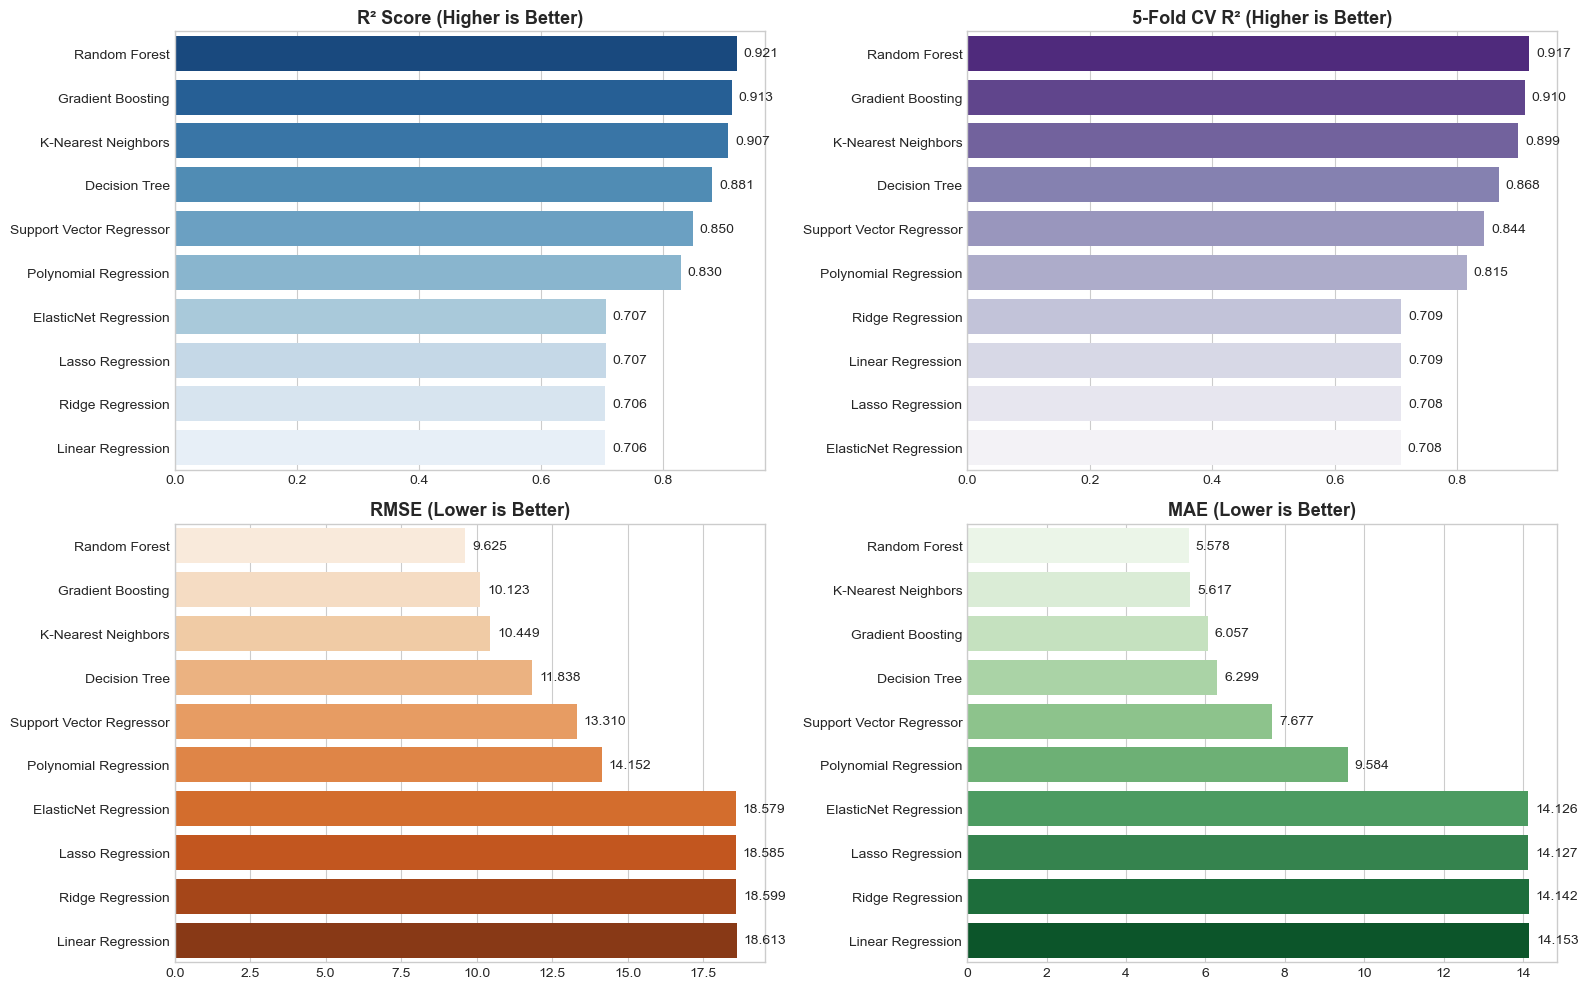

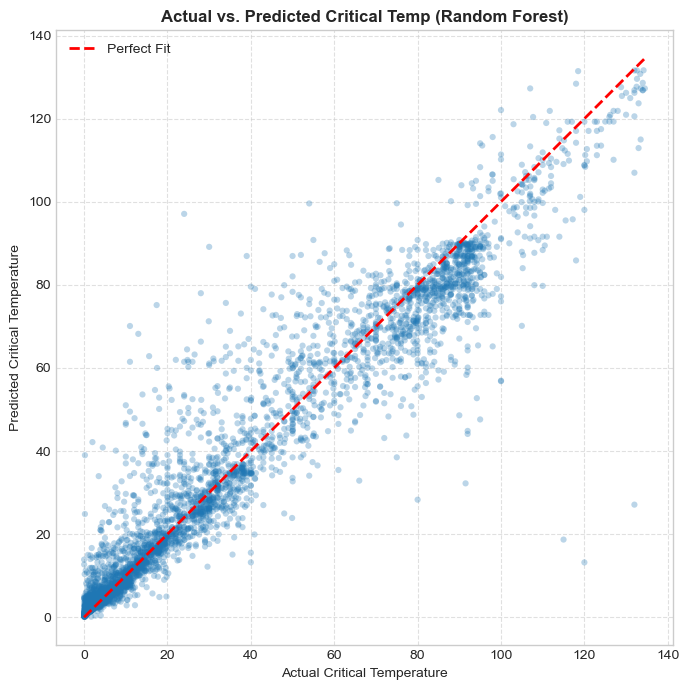

In [18]:
# 3. Comparative Visualisation Plots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

metrics = [
    ('R2 Score', 'R² Score (Higher is Better)', 'Blues_r', axes[0, 0]),
    ('5-Fold CV R2', '5-Fold CV R² (Higher is Better)', 'Purples_r', axes[0, 1]),
    ('RMSE', 'RMSE (Lower is Better)', 'Oranges', axes[1, 0]),
    ('MAE', 'MAE (Lower is Better)', 'Greens', axes[1, 1])
]

for col, title, palette, ax in metrics:
    sorted_df = results_df.sort_values(by=col, ascending=('Error' in title or col in ['RMSE', 'MAE']))
    sns.barplot(data=sorted_df, x=col, y=sorted_df.index, palette=palette, ax=ax)
    ax.set_title(title, fontsize=13, weight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f"{width:.3f}", 
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', xytext=(5, 0), 
                    textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

# 4. Actual vs. Predicted Plot for the #1 Top Model
best_model_name = results_df.index[0]
best_model_instance = best_rf if best_model_name == 'Random Forest' else best_hgb
y_best_pred = best_model_instance.predict(X_test_scaled)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_best_pred, alpha=0.3, color='#1f77b4', edgecolors='none', s=20)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.title(f'Actual vs. Predicted Critical Temp ({best_model_name})', fontsize=12, weight='bold')
plt.xlabel('Actual Critical Temperature')
plt.ylabel('Predicted Critical Temperature')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()